In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import sys
sys.path.append('../python')
import utils

In [10]:
def get(fname):
    chain, params, labels = utils.read_des_chain(fname, take=['om', 's8', 'sig8', 'a1', 'a2', 'alpha1', 'alpha2'])
    samples = utils.to_mcsamples(chain, params, labels)
    # utils.wplot(chain, params, labels)
    return samples

In [11]:
samples_2pt_map3_auto_334_344 = get('../output/test-first-run/des-y3-2pt-map3-addcross334-344-NLA.txt')
samples_2pt_map3_auto = get('../output/test-first-run/des-y3-2pt-map3.txt')
samples_2pt = get('../output/test-first-run/des-y3-2pt.txt')

['om', 's8', 'm1', 'm2', 'm3', 'm4', 'a1', 'a2', 'alpha1', 'alpha2', 'sig8', 'prior', 'like', 'post', 'weight']
Removed no burn in
['om', 's8', 'm1', 'm2', 'm3', 'm4', 'a1', 'alpha1', 'sig8', 'prior', 'like', 'post', 'weight']
Removed no burn in
['om', 's8', 'm1', 'm2', 'm3', 'm4', 'a1', 'a2', 'alpha1', 'alpha2', 'sig8', 'prior', 'like', 'post', 'weight']
Removed no burn in


<Figure size 600x600 with 0 Axes>

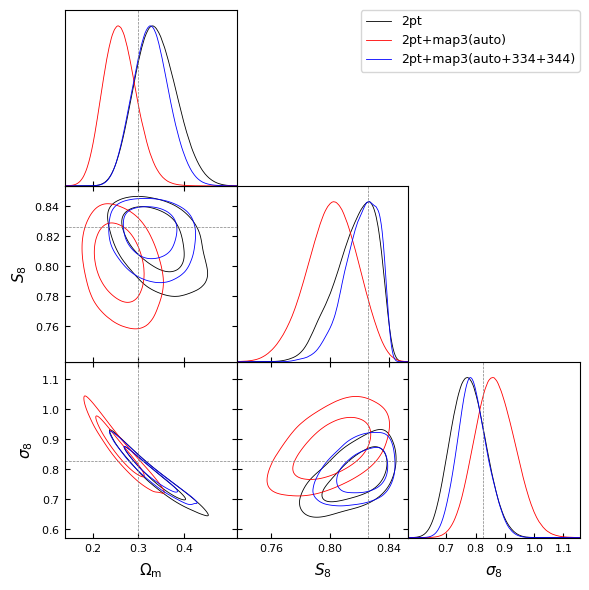

<Figure size 600x600 with 0 Axes>

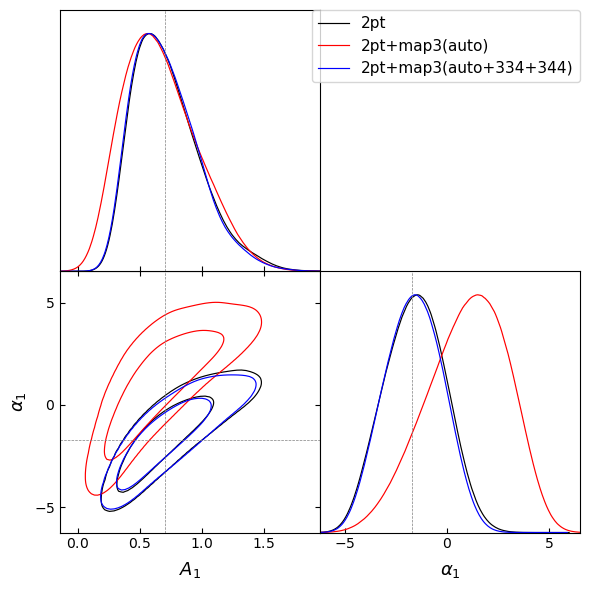

In [13]:
# COSMO
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([samples_2pt, samples_2pt_map3_auto, samples_2pt_map3_auto_334_344], ['om', 's8', 'sig8'], filled=False, \
    legend_labels=['2pt', '2pt+map3(auto)', '2pt+map3(auto+334+344)'], legend_loc='upper right', 
    # markers={'om': 0.26, 's8': 0.7999, 'sig8': 0.8593378488473191})
    markers={'om': 0.3, 's8': 0.8256, 'sig8': 0.8256})
plt.show()

# IA
g = plots.get_single_plotter(ratio=1, width_inch=6)
g.triangle_plot([samples_2pt, samples_2pt_map3_auto, samples_2pt_map3_auto_334_344], ['a1', 'alpha1'], filled=False, \
    legend_labels=['2pt', '2pt+map3(auto)', '2pt+map3(auto+334+344)'], legend_loc='upper right', markers={'a1':0.7, 'alpha1':-1.7})
plt.show()

Something is wrong with 2pt+map3(auto) chain, maybe because I made the synthetic data vector with wrong cosmo by mistake.

In [22]:
names = ['s8', 'om']
samples_list = [samples_2pt, samples_2pt_map3_auto, samples_2pt_map3_auto_334_344]
fom = np.array([utils.FoM_from_samples_names(s, names) for s in samples_list])
improve = fom/fom[0]

In [23]:
fom

array([1695.28778628, 1687.3658271 , 2138.90850157])

In [24]:
improve

array([1.        , 0.99532707, 1.26167871])